In [3]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import collections

In [4]:
file = open('fra.txt', 'r')
raw_text = file.read()
file.close()

In [5]:
def _preprocess(text):
    # Replace non-breaking space with space
    text = text.replace('\u202f', ' ').replace('\xa0', ' ')
    # Insert space between words and punctuation marks
    no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text.lower())]
    return ''.join(out)

text = _preprocess(raw_text)
print(text[:80])

go .	va !	cc-by 2 .0 (france) attribution: tatoeba .org #2877272 (cm) & #1158250


In [6]:
def _tokenize(text, max_examples=None):
    src, tgt = [], []
    for i, line in enumerate(text.split('\n')):
        if max_examples and i > max_examples: break
        parts = line.split('\t')
        if len(parts) >= 2:
            # Skip empty tokens
            src.append([t for t in f'{parts[0]} <eos>'.split(' ') if t])
            tgt.append([t for t in f'{parts[1]} <eos>'.split(' ') if t])
    return src, tgt

src, tgt = _tokenize(text)
src[:6], tgt[:6]

([['go', '.', '<eos>'],
  ['go', '.', '<eos>'],
  ['go', '.', '<eos>'],
  ['go', '.', '<eos>'],
  ['hi', '.', '<eos>'],
  ['hi', '.', '<eos>']],
 [['va', '!', '<eos>'],
  ['marche', '.', '<eos>'],
  ['en', 'route', '!', '<eos>'],
  ['bouge', '!', '<eos>'],
  ['salut', '!', '<eos>'],
  ['salut', '.', '<eos>']])

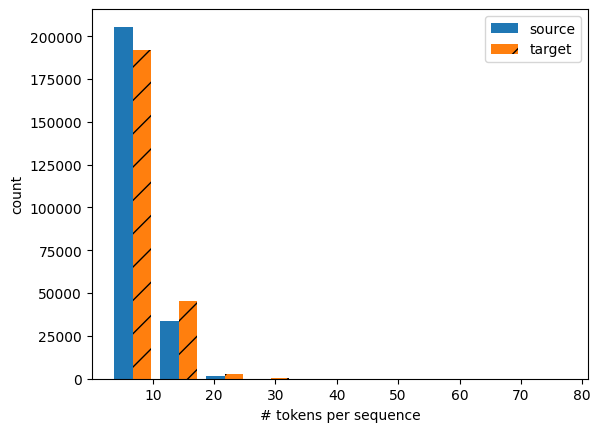

In [7]:
def show_list_len_pair_hist(legend, xlabel, ylabel, xlist, ylist):
    """Plot the histogram for list length pairs."""
    _, _, patches = plt.hist(
        [[len(l) for l in xlist], [len(l) for l in ylist]])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    for patch in patches[1].patches:
        patch.set_hatch('/')
    plt.legend(legend)

show_list_len_pair_hist(['source', 'target'], '# tokens per sequence',
                        'count', src, tgt);

In [8]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):  # Index for the unknown token
        return self.token_to_idx['<unk>']

In [9]:
def _build_array(sentences, vocab, is_tgt=False, num_steps=9):
    pad_or_trim = lambda seq, t: (
        seq[:t] if len(seq) > t else seq + ['<pad>'] * (t - len(seq)))
    sentences = [pad_or_trim(s, num_steps) for s in sentences]
    if is_tgt:
        sentences = [['<bos>'] + s for s in sentences]
    if vocab is None:
        vocab = Vocab(sentences, min_freq=2)
    array = tf.constant([vocab[s] for s in sentences])
    valid_len = tf.reduce_sum(
        tf.cast(array != vocab['<pad>'], tf.int32), 1)
    return array, vocab, valid_len

def _build_arrays(raw_text, src_vocab=None, tgt_vocab=None):
    src, tgt = _tokenize(_preprocess(raw_text))
    src_array, src_vocab, src_valid_len = _build_array(src, src_vocab)
    tgt_array, tgt_vocab, _ = _build_array(tgt, tgt_vocab, True)
    return ((src_array, tgt_array[:,:-1], src_valid_len, tgt_array[:,1:]),
            src_vocab, tgt_vocab)

In [10]:
def build(src_sentences, tgt_sentences):
    raw_text = '\n'.join([src + '\t' + tgt for src, tgt in zip(
        src_sentences, tgt_sentences)])
    arrays, _, _ = _build_arrays(
        raw_text, src_vocab, tgt_vocab)
    return arrays

In [11]:
src, tgt, _, _ = build(['hi .'], ['salut .'])

NameError: name 'src_vocab' is not defined

In [ ]:
src_vocab.to_tokens(tf.cast(src[0], tf.int32)), tgt_vocab.to_tokens(tf.cast(tgt[0], tf.int32))

(['hi', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'],
 ['<bos>', 'salut', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'])

In [ ]:
class Encoder(tf.keras.layers.Layer):
    """The base encoder interface for the encoder--decoder architecture."""
    def __init__(self):
        super().__init__()

    # Later there can be additional arguments (e.g., length excluding padding)
    def call(self, X, *args):
        raise NotImplementedError


In [ ]:
class Decoder(tf.keras.layers.Layer):
    """The base decoder interface for the encoder--decoder architecture."""
    def __init__(self):
        super().__init__()

    # Later there can be additional arguments (e.g., length excluding padding)
    def init_state(self, enc_all_outputs, *args):
        raise NotImplementedError

    def call(self, X, state):
        raise NotImplementedError

In [ ]:
class EncoderDecoder(tf.keras.Model):
    """The base class for the encoder--decoder architecture."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, enc_X, dec_X, *args):
        enc_all_outputs = self.encoder(enc_X, *args, training=True)
        dec_state = self.decoder.init_state(enc_all_outputs, *args)
        # Return decoder output only
        return self.decoder(dec_X, dec_state, training=True)[0]